# Prediction of stress at a Distance x from the center Using Random Forest

In [1]:
import pandas as pd
import numpy as np
import os

In [3]:
def get_image_input(sim_no,output,r,path):
    import pandas as pd
    import numpy as np
    import os
    sim = 998
    nodes = 9271
    #path = 'csv_files/sim_w_comb_'
    file = path + f'{sim_no}/S_U_PEEQ_COORD_{sim_no}.csv'
    if os.path.isfile(file):
       
        df = pd.read_csv(file)
        df = df.replace('       NoValue', np.nan)
        df.columns = df.columns.str.lstrip()
        x_cord = df['X']
        y_cord = df['Y']
        rho = np.zeros(len(y_cord))
        phi = np.zeros(len(y_cord))
        for i in range((len(x_cord))):
            rho[i] = np.sqrt(x_cord[i]**2 + y_cord[i]**2)
            phi[i] = np.arctan2(y_cord[i], x_cord[i])
        df['R'] = rho
        df['theta'] = phi
        df_data = df[(df['R'] > r-5) & (df['R'] < r+5)]
        df_data = df_data.astype({'PEEQ': float,'S-S11':float, 'S-S22':float, 'S-S33':float, 'S-S12':float})
        data_S11 = df_data['S-S11'].values
        data_S22 = df_data['S-S22'].values
        data_S33 = df_data['S-S33'].values
        data_S12 = df_data['S-S12'].values
        data_X = df_data['X'].values
        data_Y = df_data['Y'].values
        data_r = df_data['R'].values
        data_theta = df_data['theta'].values
        if output == 'sigmax':
            return (data_S11)
        if output == 'sigmay':
            return (data_S12)
        if output == 'sigmaz':
            return (data_S33)
        if output == 'r':
            return(data_r)
        if output == 'theta':
            return(data_theta)
        if output == 'x':
            return(data_X)
        if output == 'y':
            return(data_Y)

            
        

### Getting X input

In [25]:
# Setting up input for the model
def get_xinput(r,len1):
    import numpy as np
    a = np.zeros((len1,sim_count))
    for i in range(len(temp_in)):
        a[:,i] = get_image_input(temp_in[i],'sigmax',r, 'csv_files/sim_w_comb_')
    return a



### Getting Y output

In [28]:
# Setting up y-output
def get_youtput(r,len2):
    import numpy as np
    a = np.zeros((len2,sim_count))
    for i in range(len(temp_in)):
        a[:,i] = get_image_input(temp_in[i],'sigmax',r, 'csv_files/sim_w_comb_')
    return a


# Implementing ML model (Random Forest)

### Data Preparation

In [30]:
# r is the the radius of the cavity, x is the distance from the center of the cavity
r = 500
x = 800 
# len1, len2 is used to evaluate the no. of nodes or discretization
len1 = len(get_image_input(1,'sigmax',ro, path = 'csv_files/sim_w_comb_'))
len2 = len(get_image_input(1,'sigmax',x, path = 'csv_files/sim_w_comb_'))
temp_in= []
temp_ex = []
for i in range(1000):
    file = f'csv_files/sim_w_comb_{i}/S_U_PEEQ_COORD_{i}.csv'
    if os.path.isfile(file):
        temp_in.append(i)
    else:
        temp_ex.append(i)
sim_count = len(temp_in)
x_input = get_xinput(r,len1)
y_output = get_youtput(x,len2)
x_input = x_input.reshape(sim_count,len1)
y_output = y_output.reshape(sim_count,len2)

In [31]:
# Cases used for prediction
case = [16,134,198,312,401,632,708,795,866,987]
sigma_x = np.zeros((36,len(case)))
x1 = np.zeros((36,len(case)))
y1 = np.zeros((36,len(case)))
theta = np.zeros((128,len(case)))
for i in range(len(case)):
    sigma_x[:,i] = get_image_input(case[i],'sigmax',x,'csv_files1/sim_w_comb_' )
    x1[:,i] = get_image_input(case[i],'x',x, 'csv_files1/sim_w_comb_')
    y1[:,i] = get_image_input(case[i],'y',x, 'csv_files1/sim_w_comb_')
    theta[:,i] = get_image_input(case[i],'theta',r, 'csv_files1/sim_w_comb_')

In [35]:
# Spliting testing and training
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_input, y_output, test_size=0.2, random_state = 42)

### Hyperparameter tuning

In [49]:
par_grid  = [{'bootstrap': [True, False],
 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None],
 'max_features': ['auto', 'sqrt'],
 'min_samples_leaf': [1, 2, 4],
 'min_samples_split': [2, 5, 10],
 'n_estimators': [2, 5, 10, 20, 50]}]

In [61]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor()
from sklearn.model_selection import GridSearchCV
tune_randomforest = GridSearchCV(regressor, param_grid = par_grid ,cv = 5, verbose = True, n_jobs = -1)
tune_randomforest.fit(x_train,y_train)
# The best output parameters for model
tune_randomforest.best_params_

Fitting 5 folds for each of 1980 candidates, totalling 9900 fits


{'bootstrap': True,
 'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 4,
 'min_samples_split': 10,
 'n_estimators': 50}

In [63]:
rf_regressor = RandomForestRegressor(bootstrap= False,
 max_depth= 10,
 max_features= 'sqrt',
 min_samples_leaf= 4,
 min_samples_split= 2,
 n_estimators= 50)
rf_regressor.fit(x_train, y_train)


RandomForestRegressor(bootstrap=False, max_depth=10, max_features='sqrt',
                      min_samples_leaf=4, n_estimators=50)

In [72]:
theta = theta.reshape(len(case),len1)

In [73]:
prediction = rf_regressor.predict(theta)

In [80]:
# Evaluating the metric score
from sklearn import metrics
sigma_x = sigma_x.reshape(len(case),len2)
x1 = x1.reshape(len(case),len2)
y1 = y1.reshape(len(case),len2)
mse = metrics.mean_squared_error(sigma_x, prediction)
mse

0.0005285552991476359

In [85]:
x = np.asarray(x1[5,:])
y = np.asarray(y1[5,:])
z1 = np.asarray(prediction[5])
z_ml = z1.copy()
z2 = np.asarray(sigma_x[5,:])
z_sim = z2.copy()

In [86]:
df_sim = pd.DataFrame({'x': x, "y":y , "sigmax_randomforest":z_ml ,"sigmax_sim":z_sim})
df_sim

,x,y,sigmax_randomforest,sigmax_sim
0,-112.6090,-695.521,-0.053056,-0.065908
1,-112.6090,-695.521,-0.054611,-0.078560
2,-112.6090,-695.521,-0.053575,-0.051732
3,-112.6090,-695.521,-0.049979,-0.073978
4,-112.6090,-695.521,-0.051534,-0.074462
5,-112.6090,-695.521,-0.052046,-0.074842
6,-112.6090,-695.521,-0.054428,-0.039752
7,-112.6090,-695.521,-0.055415,-0.074320
8,-112.6090,-695.521,-0.051311,-0.047712
9,-112.6090,-695.521,-0.052322,-0.042198


In [ ]:
def get_data(w):
    import pandas as pd
    import numpy as np
    sim = 1
    nodes = 9270
    c = []
    t = []
    df_c = pd.read_csv(f'csv_files1/sim_w_comb_{w}/S_U_PEEQ_COORD_{w}.csv')
    c.append(df_c)
    df_t = pd.read_csv(f'csv_files1/sim_w_comb_{w}/sim_w_comb_{w}.txt')
    t.append(df_t)
    t_df = pd.concat(t)
    c_df = pd.concat(c)
    c_df = c_df.replace('       NoValue', np.nan)
    c_df.columns = c_df.columns.str.lstrip()
    t_df.columns = t_df.columns.str.lstrip()
    y = c_df.iloc[:,16:21]
    y = y.astype({'PEEQ': float,'S-S11':float, 'S-S22':float, 'S-S33':float, 'S-S12':float})
    df_y = pd.DataFrame({'PEEQ':y.iloc[:,0] ,'S-S11':y.iloc[:,1], 'S-S22':y.iloc[:,2], 'S-S33':y.iloc[:,3], 'S-S12':y.iloc[:,4]})
    x = t_df.iloc[:,1:]
    x_d = x.values
    list1 = []
    for i in x_d[:,4]:
        i = np.char.replace(i,"]","")
        i = np.char.replace(i," ","")
        i = float(i)
        list1.append(i)
    x_data = np.zeros((sim,5))
    x_data[:,0:4] = x_d[:,0:4]
    x_data[:,4] = list1
    np.shape(x_d)
    x_global = np.zeros(((nodes-1)*sim,5))
    for i in range(sim):
        x_global[(nodes)*i:(nodes)*(i+1),:] = x_data[i,:] 
    x_input = pd.DataFrame({'E':x_global[:,0], 'mu':x_global[:,1],'phi':x_global[:,2],'psi':x_global[:,3], 'c':x_global[:,4], 'x':c_df.iloc[:,5],'y':c_df.iloc[:,6]})
    df_global = pd.concat([x_input, df_y], axis=1)
    return(df_global)

In [ ]:
j = [16,134,198,312,401,632,708,795,866,987]
df_data = get_data(j[5])

In [ ]:
for i in range(len(df_data['x'])):
    for j in range(len(df_sim['x'])):
        if df_data['x'][i] == df_data['x'][j] or df_data['y'][i] == df_data['y'][j] :
            df_data['x'][i] == 0
            df_data['y'][i] == 0

In [ ]:
df_data.drop(df_data[df_data['x'] == 0].index, inplace = True)

In [ ]:
df_new = pd.DataFrame({'x':df_data['x'], 'y':df_data['y']})
df1 = pd.concat([df_sim,df_new], ignore_index= True)

In [ ]:
df1 = df1.fillna(0)
df1

,x,y,sigmax_randomforest_new,sigmax_randomforest,sigmax_sim
0,-112.609,-695.521,-0.056374,-0.054101,-0.065908
1,-112.609,-695.521,-0.056319,-0.054081,-0.078560
2,-112.609,-695.521,-0.054794,-0.045902,-0.051732
3,-112.609,-695.521,-0.052159,-0.047785,-0.073978
4,-112.609,-695.521,-0.053820,-0.049136,-0.074462
...,...,...,...,...,...
9185,2137.560,-473.618,0.000000,0.000000,0.000000
9186,2048.660,-909.661,0.000000,0.000000,0.000000
9187,2129.950,-927.103,0.000000,0.000000,0.000000
9188,2131.490,-770.993,0.000000,0.000000,0.000000


In [125]:
def get_data(w):
    import pandas as pd
    import numpy as np
    sim = 1
    nodes = 9270
    c = []
    t = []
    #for i in range(1,sim+1):
    
    df_c = pd.read_csv(f'csv_files1/sim_w_comb_{w}/S_U_PEEQ_COORD_{w}.csv')
    c.append(df_c)
    df_t = pd.read_csv(f'csv_files1/sim_w_comb_{w}/sim_w_comb_{w}.txt')
    t.append(df_t)
    t_df = pd.concat(t)
    c_df = pd.concat(c)
    c_df = c_df.replace('       NoValue', np.nan)
    c_df.columns = c_df.columns.str.lstrip()
    t_df.columns = t_df.columns.str.lstrip()
    # Output data for the model
    y = c_df.iloc[:,16:21]
    y = y.astype({'PEEQ': float,'S-S11':float, 'S-S22':float, 'S-S33':float, 'S-S12':float})
    df_y = pd.DataFrame({'PEEQ':y.iloc[:,0] ,'S-S11':y.iloc[:,1], 'S-S22':y.iloc[:,2], 'S-S33':y.iloc[:,3], 'S-S12':y.iloc[:,4]})
    x = t_df.iloc[:,1:]
    x_d = x.values
    list1 = []
    for i in x_d[:,4]:
        i = np.char.replace(i,"]","")
        i = np.char.replace(i," ","")
        i = float(i)
        list1.append(i)
    # for j in x_d[:,0]:
    #     i = np.char.replace(j,"[","")
    #     i = np.char.replace(j," ","")
    #     j = float(j)
    #     list2.append(i)
    x_data = np.zeros((sim,5))
    x_data[:,0:4] = x_d[:,0:4]
    x_data[:,4] = list1
    np.shape(x_d)
    x_global = np.zeros(((nodes-1)*sim,5))
    for i in range(sim):
        x_global[(nodes)*i:(nodes)*(i+1),:] = x_data[i,:] 
    x_input = pd.DataFrame({'E':x_global[:,0], 'mu':x_global[:,1],'phi':x_global[:,2],'psi':x_global[:,3], 'c':x_global[:,4], 'x':c_df.iloc[:,5],'y':c_df.iloc[:,6]})
    #x_in = np.zeros((nodes-1,7))
    df_global = pd.concat([x_input, df_y], axis=1)
#     df_global.drop(df_global[df_global['S-S11'] == 0].index, inplace = True)
#     df_global.drop(df_global[df_global['S-S22'] == 0].index, inplace = True)
#     df_global.drop(df_global[df_global['S-S33'] == 0].index, inplace = True)
#     df_global.drop(df_global[df_global['S-S12'] == 0].index, inplace = True)
    #df_global = df_global.fillna({'PEEQ': 0})
    #dd = df_global.dropna()
    #data_x = df_global.iloc[:,0:7].values
    #data_y = df_global.iloc[:,7:13].values
    
#     x_in = np.zeros((nodes-1,7))
#     for i in range(0,7):
#         x_in[:,i] = x_input.T.iloc[i]
    return(df_global)

In [198]:
j = [16,134,198,312,401,632,708,795,866,987]
df_data = get_data(j[6])

In [199]:
df_new = pd.DataFrame({'x':df_data.iloc[:,5].values,'y':df_data.iloc[:,6].values, 'sigma_x':df_data.iloc[:,8].values})

In [201]:
df_new = df_new.fillna(0)

In [202]:
df_join = pd.merge(df_new, df_sim, on=['x','y'], how='left')


In [203]:
df_join.sigmax_randomforest.isnull().sum()

9265

In [204]:
df_join = df_join.fillna(method='ffill', axis =1)

In [205]:
df_join

,x,y,sigma_x,sigmax_randomforest,sigmax_sim
0,-2500.00,2500.000,-0.013868,-0.013868,-0.013868
1,-2500.00,0.000,-0.031137,-0.031137,-0.031137
2,-2500.00,-2500.000,-0.042663,-0.042663,-0.042663
3,0.00,2500.000,-0.016149,-0.016149,-0.016149
4,0.00,-2500.000,-0.046355,-0.046355,-0.046355
...,...,...,...,...,...
9296,2137.56,-473.618,-0.033222,-0.033222,-0.033222
9297,2048.66,-909.661,-0.033861,-0.033861,-0.033861
9298,2129.95,-927.103,-0.034063,-0.034063,-0.034063
9299,2131.49,-770.993,-0.033723,-0.033723,-0.033723


,x,y,sigma_x,sigmax_randomforest,sigmax_sim


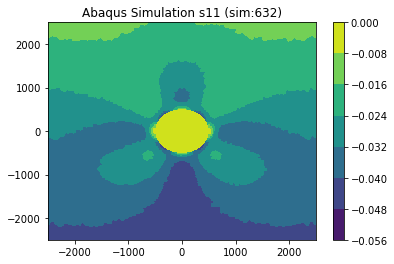

In [207]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

x = df_join['x']
y = df_join['y']
z = df_join['sigma_x']
xi = np.linspace(np.min(x), np.max(x), len(x))
yi = np.linspace(np.min(y), np.max(y), len(y))

X,Y= np.meshgrid(xi,yi)
Z = griddata((x, y), z, (X, Y),method='nearest')
plt.contourf(X,Y,Z)
plt.title("Abaqus Simulation s11 (sim:632)")
plt.colorbar()

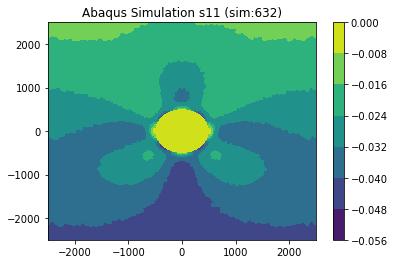

In [208]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

x = df_join['x']
y = df_join['y']
z = df_join['sigmax_randomforest']
xi = np.linspace(np.min(x), np.max(x), len(x))
yi = np.linspace(np.min(y), np.max(y), len(y))

X,Y= np.meshgrid(xi,yi)
Z = griddata((x, y), z, (X, Y),method='nearest')
plt.contourf(X,Y,Z)
plt.title("Abaqus Simulation s11 (sim:632)")
plt.colorbar()

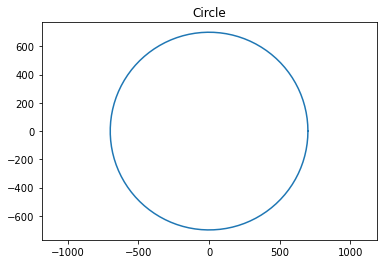

In [217]:
# importing libraries
import numpy as np
from matplotlib import pyplot as plt

# Creating equally spaced 100 data in range 0 to 2*pi
theta = np.linspace(0, 2 * np.pi, 100)

# Setting radius
radius = 700

# Generating x and y data
x = radius * np.cos(theta)
y = radius * np.sin(theta)

# Plotting
plt.plot(x, y)
plt.xlim(-200, 200)
plt.ylim(-200, 200)
plt.axis('equal')
plt.title('Circle')
plt.show()